In [1]:
#Schubert testing
X = SchubertPolynomialRing(ZZ)
R.<x0,x1,x2,x3,x4> = PolynomialRing(ZZ)
w = [1,2,4,3,5] # a list representing an element of `S_5`
print(X(w).expand())
lst = [1,1,1,1,1]
x = R(X(w).expand())(lst)
print(x)
#for w in SymmetricGroup(6):
    #principal_specializations = 


x0 + x1 + x2
3


In [39]:
Permutation([3,2,4,1]).reduced_words()

[[1, 2, 3, 1], [1, 2, 1, 3], [2, 1, 2, 3]]

In [55]:
from itertools import product

#produce all ascending p-tuple sequences with entries between 1 and top
def asc_tuples(p, top):
    res = [sorted(i) for i in product(range(1, top + 1), repeat = p)]
    cleaned_res = []
    [cleaned_res.append(i) for i in res if i not in cleaned_res]
    #res = list(set(res))
    return cleaned_res
#print(asc_tuples(2,5))

#produce all pairs with entries between 1 and top and sum <= top + 1
def rc_coords(top):
    res = [sorted(i) for i in product(range(1, top + 1), repeat = 2)]
    cleaned_res = []
    [cleaned_res.append((i[0], top+1-i[1])) for i in res if (i[0], top+1-i[1]) not in cleaned_res]
    #res = list(set(res))
    return cleaned_res

print(rc_coords(6))

[(1, 6), (1, 5), (1, 4), (1, 3), (1, 2), (1, 1), (2, 5), (2, 4), (2, 3), (2, 2), (2, 1), (3, 4), (3, 3), (3, 2), (3, 1), (4, 3), (4, 2), (4, 1), (5, 2), (5, 1), (6, 1)]


In [56]:

#check if Condition 2 of definition of a-compatible holds
def condition_2(a,alpha):
    for j in range(len(a)):
        if alpha[j] > a[j]:
            return False
    return True

#check if Condition 3 of definition of a-compatible holds
def condition_3(a,alpha):
    for j in range(len(a) - 1):
        if a[j] < a[j+1] and alpha[j] >= alpha[j+1]:
            return False
    return True

a = [4,2,1]
#alpha = [1,3,3]
#print(condition_3(a,alpha))
#Given a reduced word a, produce all a-compatible alpha
def a_compatibles(a):
    prelim = asc_tuples(len(a), max(a))
    final = []
    for i in prelim:
        if condition_2(a,i) and condition_3(a,i):
            final.append(i)
    return final
print(a_compatibles(a))

#Given a reduced word a and an a-compatible alpha, produce RC graph. this gives location of + signs in RC graph.
def rc_graph_cross(a,alpha):
    rc_graph = [(alpha[k], a[k] - alpha[k] + 1) for k in range(len(a))]
    return rc_graph

n = 6
a = [5,2,1,3,4,5]
alpha = [1,1,1,2,3,5]
print(rc_graph_cross(a,alpha))
#Given a reduced word a and an a-compatible alpha, produce RC graph. this gives location of bump signs in RC graph.
def rc_graph_bump(a,alpha):
    crosses = rc_graph_cross(a,alpha)
    bumps = [i for i in rc_coords(n) if i not in crosses]
    return bumps
print(rc_graph_bump(a,alpha))

#Given 2 RC graphs, encoded as list of bump coords, determine if there exists a chute move carrying rc1 -> rc2
#Output chute move if exists as [(i,k),(l,j)] where (i,k) is bottom left corner b4 move and (l,j) is top right after
def chute_move(rc1, rc2):
    intersection = [i for i in rc1 if i in rc2]
    if not len(intersection) + 1 == len(rc1) or not len(intersection) + 1 == len(rc2):
        return []
    for bump in rc1: # The bottom left corner, which is a blank space in the blue diagram.
        # The bottom left corner can't be empty in the red diagram.
        if bump in rc2:
            continue
        i = bump[0]; k = bump[1]
        #print(i,k)
        
        # Find all bumps that lie directly above 'bump' and choose the nearest one.
        # This guarantees that everything in the column between 'bump' and the new bump is a cross.
        rows = [cand[0] for cand in rc1 if cand[0] < i and cand[1] == k]
        #print(rows)
        if len(rows) == 0:
            continue
        top_row = max(rows)
        if (top_row, k) not in rc2:
            continue
        
        # Similarly, find the nearest bump directly to the right of 'bump'.
        columns = [cand[1] for cand in rc1 if cand[0] == i and cand[1] > k]
        if len(columns) == 0:
            continue
        right_column = min(columns)
        if (i, right_column) not in rc2:
            continue
        
        good = all(
            (row, column) not in rc1 and (
                ((row, column) in rc2) == ((row, column) == (top_row, right_column))
            )
            for row in range(top_row, i)
            for column in range(k+1, right_column+1)
        )
        if good:
            return ((i,k),(top_row,right_column))
    return None
        
#return true if there is a chute move from rc1 to rc2. This expects rc1 and rc2 to be lists of *tuples*, not lists.
def exists_chute_move_tups(rc1, rc2):
    intersection = [i for i in rc1 if i in rc2]
    if not len(intersection) + 1 == len(rc1) or not len(intersection) + 1 == len(rc2):
        return []
    for bump in rc1: #the bottom left corner, which is a blank space in the blue diagram
        #the bottom left corner can't be empty in the red diagram
        if bump in rc2:
            continue
        (i, k) = bump
        #print(i,k)
        
        #find all bumps that lie directly above 'bump' and choose the nearest one
        #this guarantees that everything in the column between 'bump' and the new bump is a cross
        rows = [cand[0] for cand in rc1 if cand[0] < i and cand[1] == k]
        #print(rows)
        if len(rows) == 0:
            continue
        top_row = max(rows)
        if (top_row, k) not in rc2:
            continue
        
        #similarly, find the nearest bump directly to the right of 'bump'
        columns = [cand[1] for cand in rc1 if cand[0] == i and cand[1] > k]
        if len(columns) == 0:
            continue
        right_column = min(columns)
        if (i, right_column) not in rc2:
            continue
        
        good = all(
            (row, column) not in rc1 and (
                ((row, column) in rc2) == ((row, column) == (top_row, right_column))
            )
            for row in range(top_row, i)
            for column in range(k+1, right_column+1)
        )
        if good:
            return True
    return False


[[1, 1, 1]]
[(1, 5), (1, 2), (1, 1), (2, 2), (3, 2), (5, 1)]
[(1, 6), (1, 4), (1, 3), (2, 5), (2, 4), (2, 3), (2, 1), (3, 4), (3, 3), (3, 1), (4, 3), (4, 2), (4, 1), (5, 2), (6, 1)]


In [57]:
#testing chute_move
n = 6
crosses_1 = [(2,2), (3,1), (3,2), (3,3), (5,1)] #blue
crosses_2 = [(3,2), (3,1), (3,3), (4,1), (5,1)] #red
crosses_3 = [(1,3), (3,1), (3,2), (3,3), (5,1)]
total = rc_coords(n)
bumps_1 = [i for i in total if i not in crosses_1]
bumps_3 = [i for i in total if i not in crosses_3]
# print(bumps_1)
# print(bumps_2)
#print(chute_move(bumps_1, bumps_2)) #must face in direction of arrow as given in poset diagram in Rubey

#testing sorting functions in python
sorted_c1 = sorted(crosses_1, key=lambda x: (x[0], x[1]))
sorted_c2 = sorted(crosses_2, key=lambda x: (x[0], x[1]))
sorted_c3 = sorted(crosses_3, key=lambda x: (x[0], x[1]))
candidates = [sorted_c1, sorted_c2, sorted_c3]
sorted_candidates = sorted(candidates, key=lambda x: x[0]) #is this as intended?
print(sorted_candidates)

[[(1, 3), (3, 1), (3, 2), (3, 3), (5, 1)], [(2, 2), (3, 1), (3, 2), (3, 3), (5, 1)], [(3, 1), (3, 2), (3, 3), (4, 1), (5, 1)]]


In [5]:
#testing figure 4 in Rubey
n = 5
total = [(cell[0], cell[1]) for cell in rc_coords(n)]
for pi in SymmetricGroup(n):
    if all(pi(i) == i for i in IntegerRange(1, n+1)):
        continue
    perm = [pi(i) for i in IntegerRange(1, n+1)]
    red_words = Permutation(perm).reduced_words()
#     print(red_words)
    rc_graph_crosses = []
    for word in red_words:
        for alpha in a_compatibles(word):
            crosses = [(cross[0], cross[1]) for cross in rc_graph_cross(word, alpha)]
            rc_graph_crosses.append(frozenset(crosses))
    #     print(len(rc_graph_crosses)) #checks out

    rc_digraph = DiGraph([
        rc_graph_crosses,
        [
            (rc1, rc2)
            for rc1 in rc_graph_crosses
            for rc2 in rc_graph_crosses
            if exists_chute_move_tups([p for p in total if p not in rc1], [p for p in total if p not in rc2])
        ]
    ])
    rc_poset = LatticePoset(Poset(rc_digraph))
    print(f"{perm}: Success")

[5, 1, 2, 3, 4]: Success
[2, 1, 3, 4, 5]: Success
[4, 5, 1, 2, 3]: Success
[3, 4, 5, 1, 2]: Success
[1, 5, 2, 3, 4]: Success
[5, 4, 1, 2, 3]: Success
[2, 5, 1, 3, 4]: Success


KeyboardInterrupt: 

In [6]:
#lattice testing: call LatticePoset to check if a poset is a lattice
uc = [[2,3], [], [1], [1], [1], [3,4]]
from sage.combinat.posets.posets import FinitePoset
P = FinitePoset(DiGraph(dict([[i,uc[i]] for i in range(len(uc))])), facade=False)
P.cover_relations()
LatticePoset(P)


ValueError: not a meet-semilattice: no bottom element

In [58]:
perm = [1,2,6,4,5,3]
n = 6
total = [(cell[0], cell[1]) for cell in rc_coords(n)]
red_words = Permutation(perm).reduced_words()
#     print(red_words)
rc_graph_crosses = []
for word in red_words:
    for alpha in a_compatibles(word):
        crosses = [(cross[0], cross[1]) for cross in rc_graph_cross(word, alpha)]
        rc_graph_crosses.append(frozenset(crosses))
#     print(len(rc_graph_crosses)) #checks out

rc_digraph = DiGraph([
    rc_graph_crosses,
    [
        (rc1, rc2)
        for rc1 in rc_graph_crosses
        for rc2 in rc_graph_crosses
        if exists_chute_move_tups([p for p in total if p not in rc1], [p for p in total if p not in rc2])
    ]
])
rc_poset = LatticePoset(Poset(rc_digraph))
print(f"{perm}: Success")

[1, 2, 6, 4, 5, 3]: Success


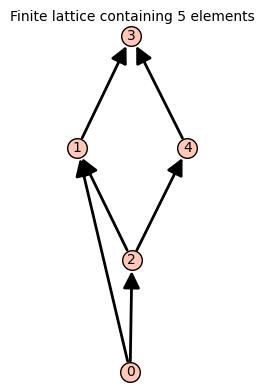

In [59]:
#given a poset P, check the following condition.
#let z in P. if distinct x,y are both covered by z, then there is a meet w of x,y so that [w,z] is DIAMOND
def is_diamond(z,P):
    xy_candidates= P.common_lower_covers([z])
    for x in xy_candidates:
        for y in xy_candidates:
            if x != y:
                w = P.meet(x,y)
                if w == None:
                    return False
                else:
                    interval_wz = P.interval(w,z)
                    return (len(interval_wz) == 4)
    return True #because if xy_candidates is empty, then its vacuously true

#given a poset P, check the following condition.
#let z in P. if distinct x,y are both covered by z, then there is a meet w of x,y so that [w,z] is PENTAGON
def is_pentagon(z,P):
    xy_candidates= P.common_lower_covers([z])
    for x in xy_candidates:
        for y in xy_candidates:
            if x != y:
                w = P.meet(x,y)
                if w == None:
                    return False
                else:
                    interval_wz = P.interval(w,z)
                    subposet = P.subposet(interval_wz)
                    G = subposet.cover_relations_graph()
                    if len(interval_wz) == 5 and G.size() == 5:
                        return True
                    else:
                        return False
    return True #because if xy_candidates is empty, then its vacuously true

#function testing
#uc = [[1,2,3],[4],[4],[4],[]]
#uc = [[1,2],[3], [3],[]]
uc = [[1,2],[3],[1,4],[],[3]]
from sage.combinat.posets.posets import FinitePoset
P = FinitePoset(DiGraph(dict([(i,uc[i]) for i in range(len(uc))])), facade=False)
#P.cover_relations()
LatticePoset(P)
#is_diamond(3,P)
#is_pentagon(3,P)

In [46]:
#testing colin conjecture
n = 4
total = [(cell[0], cell[1]) for cell in rc_coords(n)]
for pi in SymmetricGroup(n):
    if all(pi(i) == i for i in IntegerRange(1, n+1)):
        continue
    perm = [pi(i) for i in IntegerRange(1, n+1)]
    red_words = Permutation(perm).reduced_words()
#     print(red_words)
    rc_graph_crosses = []
    for word in red_words:
        for alpha in a_compatibles(word):
            crosses = [(cross[0], cross[1]) for cross in rc_graph_cross(word, alpha)]
            rc_graph_crosses.append(frozenset(crosses))
    #     print(len(rc_graph_crosses)) #checks out

    rc_digraph = DiGraph([
        rc_graph_crosses,
        [
            (rc1, rc2)
            for rc1 in rc_graph_crosses
            for rc2 in rc_graph_crosses
            if exists_chute_move_tups([p for p in total if p not in rc1], [p for p in total if p not in rc2])
        ]
    ])
    rc_pos = Poset(rc_digraph)
    rc_poset = LatticePoset(rc_pos)
    print(f"{perm}: Success")
    bot = rc_pos.bottom()
    top = rc_pos.top()
    elts = rc_pos.closed_interval(bot, top)
    for z in elts:
        if is_diamond(z,rc_pos) or is_pentagon(z,rc_pos):
            print('')
        else:
            print('false')

[3, 4, 1, 2]: Success

[4, 3, 2, 1]: Success

[2, 1, 4, 3]: Success



[1, 3, 4, 2]: Success



[3, 1, 2, 4]: Success

[4, 2, 1, 3]: Success

[2, 4, 3, 1]: Success


[1, 4, 2, 3]: Success



[3, 2, 4, 1]: Success

[4, 1, 3, 2]: Success


[2, 3, 1, 4]: Success

[1, 2, 4, 3]: Success



[3, 4, 2, 1]: Success

[4, 3, 1, 2]: Success

[2, 1, 3, 4]: Success

[1, 3, 2, 4]: Success


[3, 1, 4, 2]: Success


[4, 2, 3, 1]: Success

[2, 4, 1, 3]: Success


[1, 4, 3, 2]: Success





[3, 2, 1, 4]: Success

[4, 1, 2, 3]: Success

[2, 3, 4, 1]: Success



In [60]:
#testing colin conjecture
n = 6
total = [(cell[0], cell[1]) for cell in rc_coords(n)]

perm = [2,1,6,5,4,3]
red_words = Permutation(perm).reduced_words()
#     print(red_words)
rc_graph_crosses = []
for word in red_words:
    for alpha in a_compatibles(word):
        crosses = [(cross[0], cross[1]) for cross in rc_graph_cross(word, alpha)]
        rc_graph_crosses.append(frozenset(crosses))
#     print(len(rc_graph_crosses)) #checks out

rc_digraph = DiGraph([
    rc_graph_crosses,
    [
        (rc1, rc2)
        for rc1 in rc_graph_crosses
        for rc2 in rc_graph_crosses
        if exists_chute_move_tups([p for p in total if p not in rc1], [p for p in total if p not in rc2])
    ]
])
rc_pos = Poset(rc_digraph)
#rc_poset = LatticePoset(rc_pos)
#print(f"{perm}: Success")
#FIND ALL DIAMONDS IN rc_pos
for x in rc_pos:
    for y in rc_pos:
        m = rc_pos.meet(x,y)
        j = rc_pos.join(x,y)
        covers = rc_pos.covers(m,x) and rc_pos.covers(m,y) and rc_pos.covers(x,j) and rc_pos.covers(y,j)
        if covers and not(x == y or x == m or x == j or y == m or y == j or m == j):
            print(x)
            print(y)
            print(m)
            print(j)
            print()

KeyboardInterrupt: 

In [ ]:
#given a tuple of bump locations in RC graph and the underlying permutation, give the northeast numbered RC graph
#output is labels of the northest numbered RC graph left to right, top to bottom
#staircase shape (n,n-1,...,1) with number of dots (hyperbola pieces) northeast, including the square itself
#rows labeled 1 thru n, cols labeled 1 thru n, box labeled (row, col)
def northeast(perm,rc_graph_bumps):
    n = len(perm)
    lst = []
    for i in range(1,n+1):
        for j in range(1,n+1):
            #northeast_count = 0
            if i + j <= n+1:
                bumps = [bump for bump in rc_graph_bumps if bump[0]<= i and bump[1] >= j] #if condition is NE
                lst.append(len(bumps))
    return lst

#same as above but SW instead of NE
def southwest(perm,rc_graph_bumps):
    n = len(perm)
    lst = []
    for i in range(1,n+1):
        for j in range(1,n+1):
            #northeast_count = 0
            if i + j <= n+1:
                bumps = [bump for bump in rc_graph_bumps if bump[0]>= i and bump[1] <= j] #if condition is SW
                lst.append(len(bumps))
    return lst

def northwest(perm,rc_graph_bumps):
    n = len(perm)
    lst = []
    for i in range(1,n+1):
        for j in range(1,n+1):
            #northeast_count = 0
            if i + j <= n+1:
                bumps = [bump for bump in rc_graph_bumps if bump[0]<= i and bump[1] <= j] #if condition is NW
                lst.append(len(bumps))
    return lst

def southeast(perm,rc_graph_bumps):
    n = len(perm)
    lst = []
    for i in range(1,n+1):
        for j in range(1,n+1):
            #northeast_count = 0
            if i + j <= n+1:
                bumps = [bump for bump in rc_graph_bumps if bump[0]>= i and bump[1] >= j] #if condition is NW
                lst.append(len(bumps))
    return lst

In [ ]:
bumps = [[1,1], [1,2], [1,3], [1,6], [2,1], [2,2], [2,3], [2,4], [2,5], [3,2], [3,3], [3,4], [4,2], [4,3], [5,2], [6,1]]
perm = [1,2,6,5,4,3]
ne = northeast(perm,bumps)
print(ne)

In [61]:
#given list1 and list2 of the same length, check if list1[i]<= list2[i] for all i
def leq(list1,list2):
    test_list = [list1[i] <= list2[i] for i in range(len(list1))]
    return all(test_list)

list1 = [1,1,1]
list2 = [1,1,0]
print(leq(list1,list2))

False


In [62]:
n = 5
perm = [1,2,4,3,5]
red_words = Permutation(perm).reduced_words()
#     print(red_words)
rc_graph_crosses = []
for word in red_words:
    for alpha in a_compatibles(word):
        crosses = [(cross[0], cross[1]) for cross in rc_graph_cross(word, alpha)]
        rc_graph_crosses.append(frozenset(crosses))
#     print(len(rc_graph_crosses)) #checks out

rc_digraph = DiGraph([
    rc_graph_crosses,
    [
        (rc1, rc2)
        for rc1 in rc_graph_crosses
        for rc2 in rc_graph_crosses
        if exists_chute_move_tups([p for p in total if p not in rc1], [p for p in total if p not in rc2])
    ]
])
rc_pos = Poset(rc_digraph)
print(rc_pos)
def crosses_to_bumps(crosses,n):
    total = rc_coords(n)
    bumps = [i for i in total if i not in crosses]
    return bumps
#crosses_1 = [[2,2], [3,1], [3,2], [3,3], [5,1]]

#for i in rc_pos:
    #for j in rc_pos:
        #print(i)
        #print(j)
        #nei = northeast(perm, crosses_to_bumps(i,n))
        #nej = northeast(perm, crosses_to_bumps(j,n))
        #if leq(nei,nej): 
            #if not rc_pos.is_less_than(i,j):
                #print("failure")
                #print("smaller")
                #print(i)
                #print("larger")
                #print(j)
            #else:
                #print("success")
        #sanity checking
        #if rc_pos.is_less_than(i,j):
            #if not leq(nei,nej):
                #print("failure")
            #else:
                #print("success")


Finite poset containing 3 elements


In [63]:
#given a pipe dream as a list of cross locations, return a dictionary in the form
#pipe number: set of rows of boxes that the pipe passes through vertically
def pipe_dict(rc_crosses,n):
    pd = {}
    for i in range(1,n+1):
        tile_row_set = set()
        tile_row = i
        tile_col = 1
        tile = (tile_row, tile_col)
        indicator = 0
        if tile in rc_crosses:
            indicator = 2
        while tile_row >= 1:
            if indicator == 0 or indicator == 3:
                if indicator == 3:
                    tile_row_set.add(tile_row)
                tile_row -= 1
                tile = (tile_row, tile_col)
                if tile in rc_crosses:
                    indicator = 3
                else:
                    indicator = 1
            elif indicator == 1 or indicator == 2:
                #if indicator == 2:
                    #tile_set.add(tile)
                tile_col += 1
                tile = (tile_row, tile_col)
                if tile in rc_crosses:
                    indicator = 2
                else:
                    indicator = 0
        pd.update({i:tile_row_set})
    return pd

In [126]:
n = 6
#1: (1,3), (1,4), (1,5), (2,3), (3,3)
#2: (1,3), (1,4), (1,5), (2,3), (4,2)
#3: (1,3), (2,2), (1,5), (2,3), (3,3)
#4: (1,3), (1,4), (1,5), (3,2), (4,2)
#5: (1,3), (1,4), (1,5), (2,3), (5,1)
#6: (1,3), (1,5), (2,2), (2,3), (4,2)
#7: (1,3), (2,2), (2,3), (2,4), (3,3)
#8: (1,3), (1,5), (2,3), (3,1), (3,3)
#9: (1,3), (1,4), (1,5), (3,2), (5,1)
#10: (1,4), (1,5), (2,2), (3,2), (4,2)
#11: (1,3), (1,5), (2,2), (2,3), (5,1)
#12: (1,3), (2,2), (2,3), (2,4), (4,2)
#13: (1,3), (1,5), (2,3), (3,1), (4,2)
#14: (1,3), (2,3), (2,4), (3,1), (3,3)
#15: (1,3), (1,4), (1,5), (4,1), (5,1)
#16: (1,4), (1,5), (2,2), (3,2), (5,1)
#17: (1,5), (2,2), (2,3), (3,2), (4,2)
#18: (1,3), (2,2), (2,3), (2,4), (5,1)
#19: (1,3), (1,5), (2,3), (3,1), (5,1)
#20: (1,3), (1,5), (3,1), (3,2), (4,2)
#21: (1,3), (2,3), (2,4), (3,1), (4,2)
#22: (1,4), (1,5), (2,2), (4,1), (5,1)
#23: (1,5), (2,2), (2,3), (3,2), (5,1)
#24: (2,2), (2,3), (2,4), (3,2), (4,2)
#25: (1,5), (2,2), (3,1), (3,2), (4,2)
#26: (1,3), (1,5), (3,1), (3,2), (5,1)
#27: (1,3), (2,3), (2,4), (3,1), (5,1)
#28: (1,3), (2,4), (3,1), (3,2), (4,2)
#29: (1,3), (2,3), (3,1), (3,2), (3,3)
#30: (1,4), (1,5), (3,1), (4,1), (5,1)
#31: (1,5), (2,2), (2,3), (4,1), (5,1)
#32: (2,2), (2,3), (2,4), (3,2), (5,1)
#33: (1,5), (2,2), (3,1), (3,2), (5,1)
#34: (2,2), (2,4), (3,1), (3,2), (4,2)
#35: (1,3), (2,4), (3,1), (3,2), (5,1)
#36: (1,3), (3,1), (3,2), (3,3), (4,2)
#37: (1,5), (2,3), (3,1), (4,1), (5,1)
#38: (2,2), (2,3), (2,4), (4,1), (5,1)
#39: (2,2), (2,4), (3,1), (3,2), (5,1)
#40: (2,2), (3,1), (3,2), (3,3), (4,2)
#41: (1,3), (3,1), (3,2), (3,3), (5,1)
#42: (2,3), (2,4), (3,1), (4,1), (5,1)
#43: (1,5), (3,1), (3,2), (4,1), (5,1)
#44: (2,2), (3,1), (3,2), (3,3), (5,1)
#45: (2,4), (3,1), (3,2), (4,1), (5,1)
#46: (3,1), (3,2), (3,3), (4,1), (5,1)
crosses = {(3,1), (3,2), (3,3), (4,1), (5,1)}
p = pipe_dict(crosses,n)
print(p)

{1: set(), 2: set(), 3: set(), 4: {3}, 5: {3}, 6: {3, 4, 5}}


In [64]:
#given a pipe dream as a list of cross locations, return a dictionary in the form
#pipe number: set of cols of boxes that the pipe passes through horizontally
#(this gives the Psi tuple)
def pipe_dict_2(rc_crosses,n):
    pd = {}
    for i in range(1,n+1):
        tile_col_set = set()
        tile_row = i
        tile_col = 1
        tile = (tile_row, tile_col)
        indicator = 0
        if tile in rc_crosses:
            indicator = 2
        while tile_row >= 1:
            if indicator == 0 or indicator == 3:
                
                tile_row -= 1
                tile = (tile_row, tile_col)
                if tile in rc_crosses:
                    indicator = 3
                else:
                    indicator = 1
            elif indicator == 1 or indicator == 2:
                if indicator == 2:
                    tile_col_set.add(tile_col)
                tile_col += 1
                tile = (tile_row, tile_col)
                if tile in rc_crosses:
                    indicator = 2
                else:
                    indicator = 0
        pd.update({i:tile_col_set})
    return pd

In [65]:
crosses = {(1,3),(1,4),(1,5),(2,3),(3,3)}
p = pipe_dict(crosses,n)
print(p)

{1: set(), 2: set(), 3: set(), 4: {1}, 5: {1}}


In [66]:
crosses = {(1,3), (1,5), (3,1), (3,2), (4,2)}
p = pipe_dict_2(crosses,n)
print(p)

{1: set(), 2: set(), 3: {1, 2, 5}, 4: {3}, 5: {2}}


In [67]:
crosses = {(3,1), (3,2), (3,3), (4,1), (4,2), (5,1)}
p = pipe_dict(crosses,n)
print(p)

{1: set(), 2: set(), 3: set(), 4: {3}, 5: {3, 4}}


In [207]:
##### work with inversions tableau starts here #####
#given a set of cross locations in an rc graph and size of rc graph (no. of rows), 
#retrieve corresponding permutation
def perm_from_rc_graph(rc_crosses, n):
    pipe_ends = []
    for i in range(1,n+1):
        tracker = (i,1)
        #0 means upper elbow
        #1 means lower elbow
        #2 means horizontal cross
        #3 means vertical cross
        indicator = 0
        if tracker in rc_crosses:
            indicator = 2
        while tracker[0] > 1 or (tracker[0] == 1 and indicator == 1) or (tracker[0] == 1 and indicator == 2):
            #go up
            if indicator == 0 or indicator == 3:
                tracker = (tracker[0] - 1, tracker[1])
                #print('beep')
            #go right (indicator is 1 or 2)
            elif indicator == 1 or indicator == 2:
                tracker = (tracker[0], tracker[1] + 1)
                #print('boop')
            #update indicator based on updated tracker
            if tracker in rc_crosses:
                if indicator == 0:
                    indicator = 3
                elif indicator == 1:
                    indicator = 2
                elif indicator == 2:
                    indicator = 2
                elif indicator == 3:
                    indicator = 3
            elif tracker not in rc_crosses:
                if indicator == 0:
                    indicator = 1
                elif indicator == 1:
                    indicator = 0
                elif indicator == 2:
                    indicator = 0
                elif indicator == 3:
                    indicator = 1
        pipe_ends.append(tracker)
    print(pipe_ends)
    inverse_perm = [i[1] for i in pipe_ends]
    actual_perm = [1 + perm.index(i) for i in range(1,len(inverse_perm) + 1)]
    return actual_perm
    
# n = 6
# crosses = {(1,3), (1,4), (1,5), (2,3), (3,3)}
n = 5
crosses = {(1,1), (1,4), (2,1), (2,2), (3,2)}
perm = perm_from_rc_graph(crosses,n)
print(perm)
                

[(1, 2), (1, 5), (1, 1), (1, 4), (1, 3)]
[3, 1, 5, 4, 2]


In [ ]:
#inversions tableau are stored as pair (dict, n) where 
#n is the number of values in the permutation that the inversions tableau is for
#entries in dictionary are, for each green box, (xcoord, ycoord): value 
#for example in LHS of illustration for Example 3.13 in inversions_tableaux_2.pdf
#the dictionary could be written as
#{(2,1): 1, (3,1): 1, (6,1): 1, (3,2): 2, (6,2): 2, (6,4): 4, (6,5): 5}
#please input dictionary so that the keys are sorted in lex order or in order of second coord then first coord
#ok maybe change dictionary to list of lists.
#change to
#[[(2,1), 1], [(3,1), 1], [(6,1), 1], [(3,2), 2], [(6,2), 2], [(6,4), 4], [(6,5), 5]]
#Say a Lehmer tableaux is any tableaux where we put whatever the heck non-negative integers 
#we feel like into the green shaded boxes
#old function
#convert inversions tableau to lehmer tableau
#make sure input format of inversions tableau is correct
# def IT_to_LT(IT,n):
#     main_dict = {}
#     for i in range(2,n+1):
#         filtered_dict = {key: IT[key] for key in IT.keys() if key[0] == i}
#         perm = list(filtered_dict.values())
#         lc = lehmer(perm)
#         keys = list(filtered_dict.keys())
#         #print(keys)
#         new_filtered_dict = {keys[i]: lc[i] for i in range(len(lc))}
#         main_dict.update(new_filtered_dict)
#     listify = main_dict.items()
#     listify = sorted(listify, key= lambda x: x[0][1])
#     new_main_dict = dict(listify)
#     return new_main_dict

In [200]:

#identify, for a cross, what pipes participate in it
#cross should be inputted as a TUPLE (crossx, crossy) not a LIST
#n is number of rows in rc graph
#return [horizontal,vertical]
def pipes_in_cross(rc_crosses,cross,n):
    pipe_ends = []
    pipes_in_cross = [0,0]
    for i in range(1,n+1):
        tracker = (i,1)
        #0 means upper elbow
        #1 means lower elbow
        #2 means horizontal cross
        #3 means vertical cross
        indicator = 0
        if cross not in rc_crosses:
            print("cross is not in the rc graph")
            return None
        if tracker in rc_crosses:
            indicator = 2
            if tracker == cross:
                pipes_in_cross[0] = i
        while tracker[0] > 1 or (tracker[0] == 1 and indicator == 1) or (tracker[0] == 1 and indicator == 2):
            #go up
            if indicator == 0 or indicator == 3:
                tracker = (tracker[0] - 1, tracker[1])
                #print('beep')
            #go right (indicator is 1 or 2)
            elif indicator == 1 or indicator == 2:
                tracker = (tracker[0], tracker[1] + 1)
                #print('boop')
            #update indicator based on updated tracker
            if tracker in rc_crosses:
                if indicator == 0:
                    indicator = 3
                    if tracker == cross:
                        #1
                        pipes_in_cross[1] = i
                elif indicator == 1:
                    indicator = 2
                    if tracker == cross:
                        #0
                        pipes_in_cross[0] = i
                elif indicator == 2:
                    indicator = 2
                    if tracker == cross:
                        #0
                        pipes_in_cross[0] = i
                elif indicator == 3:
                    indicator = 3
                    if tracker == cross:
                        #1
                        pipes_in_cross[1] = i
            elif tracker not in rc_crosses:
                if indicator == 0:
                    indicator = 1
                elif indicator == 1:
                    indicator = 0
                elif indicator == 2:
                    indicator = 0
                elif indicator == 3:
                    indicator = 1
    return pipes_in_cross
n = 6
crosses = {(1,3), (1,4), (1,5), (2,3), (3,3)}
cross = (1,3)
#print(pipes_in_cross(crosses, cross, n))


    

#given rc graph (as cross set), find corresponding inversions tableau
def rc_to_IT(rc_crosses,n):
    IT = []
    for cross in rc_crosses:
        pipe_loc = pipes_in_cross(rc_crosses,cross,n)
        locx = pipe_loc[1]
        locy = pipe_loc[0]
        IT.append([(locx, locy), cross[0]])
    IT = sorted(IT, key= lambda x: x[0][1])
    return IT

crosses = {(1,1), (1,4), (2,1), (2,2), (3,2)}
print(rc_to_IT(crosses,n))
        

[[(3, 1), 1], [(3, 2), 2], [(4, 2), 1], [(5, 2), 2], [(5, 4), 3]]


In [211]:
#COME BACK LATER - there's probably a bug here
#given inversions tableau, find corresponding rc graph (as cross set)
def IT_to_rc(rc_crosses,n):
    pass
#IT = [[(3, 1), 1], [(3, 2), 2], [(4, 2), 1], [(5, 2), 2], [(5, 4), 3]]
n=5
crosses = {(1,1), (1,4), (2,1), (2,2), (3,2)}
print(IT_to_rc(IT,n))

None


In [ ]:
#compute lehmer code of a partial permutation, inputted as a list
def lehmer(perm):
    lc = []
    for i in range(len(perm)):
        lehmer_contributors = [j for j in list(range(1,perm[i])) if j not in perm[:i]]
        lc.append(len(lehmer_contributors))
    return lc

#perm = [3,1,5,4,2]
perm = [1,2,4,5]
#print(lehmer(perm))

#convert inversions tableau to lehmer tableau
def IT_to_LT(IT,n):
    main_lst = []
    for i in range(2,n+1):
        filtered_IT = [val for val in IT if val[0][0] == i]
        if len(filtered_IT) == 0:
            continue
        perm = [val[1] for val in filtered_IT]
        lc = lehmer(perm)
        new_filtered_IT = [[filtered_IT[i][0], lc[i]] for i in range(len(lc))]
        for j in new_filtered_IT:
            main_lst.append(j)
    main_lst = sorted(main_lst, key= lambda x: x[0][1])
    return main_lst

#IT = {(2,1): 1, (3,1): 1, (6,1): 1, (3,2): 2, (6,2): 2, (6,4): 4, (6,5): 5}
IT = [[(2,1), 1], [(3,1), 1], [(6,1), 1], [(3,2), 2], [(6,2), 2], [(6,4), 4], [(6,5), 5]]
LT = IT_to_LT(IT,6)
#print(IT)

#given a lehmer code, retrieve the (partial) permutation
#n is 1 more than the height of the figure the lehmer code is taken from
def perm_from_lehmer(lc,n):
    candidates = list(range(1,n+1))
    w = [lc[0] + 1]
    candidates.remove(w[0])
    for i in range(1,len(lc)):
        for j in candidates:
            lehmer_contributors = len(list(set(list(range(1,j))).difference(set(w))))
            if lehmer_contributors == lc[i]:
                w.append(j)
                candidates.remove(j)
                continue
    return w
#print(perm_from_lehmer([2, 0, 2, 1, 0],5))
#print(perm_from_lehmer([0, 0, 1, 1],6))

#convert lehmer tableau to inversions tableau
def LT_to_IT(LT,n):
    main_lst = []
    for i in range(2,n+1):
        filtered_LT = [val for val in LT if val[0][0] == i]
        if len(filtered_LT) == 0:
            continue
        lc = [val[1] for val in filtered_LT]
        perm = perm_from_lehmer(lc,n)
        new_filtered_LT = [[filtered_LT[i][0], perm[i]] for i in range(len(perm))]
        for j in new_filtered_LT:
            main_lst.append(j)
    main_lst = sorted(main_lst, key= lambda x: x[0][1])
    return main_lst

LT = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
IT = LT_to_IT(LT,6)
#print(IT)


In [173]:
#modify lehmer tableau by adding 1 to a specified subset of boxes in a single row
#enter the boxes to increment as a set
def increment_LT(LT, boxes_to_increment):
    boxes = list(boxes_to_increment)
    boxes_y = [box[1] for box in boxes]
    boxes_y_noduplicates = list(set(list(boxes_y)))
    #if y-coordinates not all the same, stop
    if len(boxes_y_noduplicates) != 1:
        print("all boxes must be in the same row. please try again")
        return None
    else:
        for i in range(len(LT)):
            if LT[i][0] in boxes:
                LT[i][1] +=1
    return LT

boxes = {(2,1), (6,1)}
LT = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
# print(increment_LT(LT, boxes))

#given 2 valid lehmer tableau T1 and T2, check if every element entry of T1 is <= corresp entry in T2
def T1_leq_T2(T1, T2):
    T1_green = [box[0] for box in T1]
    T2_green = [box[0] for box in T2]
    if not T1_green == T2_green:
        return False
    else:
        T1_vals = [box[1] for box in T1]
        T2_vals = [box[1] for box in T2]
        for i in range(len(T1_vals)):
            if T1_vals[i] > T2_vals[i]:
                return False
        return True

LT1 = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
LT2 = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
#print(T1_leq_T2(LT1,LT2))


#given 2 valid lehmer tableau T1 and T2, check if T2 can be obtained from T1 by adding one to some subset (possibly empty)
#of boxes in a row
def T2_from_T1(T1, T2):
    T1_green = [box[0] for box in T1]
    T2_green = [box[0] for box in T2]
    boxes = []
    if not T1_green == T2_green:
        return False
    else:
        T1_vals = [box[1] for box in T1]
        T2_vals = [box[1] for box in T2]
        for i in range(len(T1_vals)):
            if T1_vals[i] > T2_vals[i]:
                return False
            elif T1_vals[i] < T2_vals[i]:
                boxes.append(T1[i][0])
        boxes_y = [box[1] for box in boxes]
        boxes_y_noduplicates = list(set(list(boxes_y)))
        if len(boxes_y_noduplicates) > 1:
            return False
        return True
    
LT1 = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
LT2 = [[(2, 1), 1], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]
#print(T2_from_T1(LT1,LT2))

[[(2, 1), 1], [(3, 1), 1], [(6, 1), 1], [(3, 2), 2], [(6, 2), 2], [(6, 4), 4], [(6, 5), 5]]
[[(2, 1), 1], [(3, 1), 1], [(6, 1), 1], [(3, 2), 2], [(6, 2), 2], [(6, 4), 4], [(6, 5), 5]]


In [156]:
n=6
#given inversions tableau, check if it is valid using Corollary 3.8 from inversions_tableaux_2.pdf
def valid(IT,n):
    IT_green = [entry[0] for entry in IT]
    for j in range(n-1,0,-1):
        for i in range(2,n+1):
            for l in range(n-1,0,-1):
                for k in range(2,n+1):
                    #first 2 conditions confirm that (i,j) and (k,l) are both possible boxes in the staircase
                    #second 2 conditions confirm that (i,j) lies to the lower left of (k,l)
                    #which avoids double counting and cases where the green boxes are in the same row or col
                    if i > j and k > l and i < k and j < l and (i,j) in IT_green and (k,l) in IT_green:
                        orange = (max(i,k), min(j,l))
                        if orange not in IT_green:
                            return False
                        else:
                            orange_index = IT_green.index(orange)
                            green1 = IT_green.index((i,j))
                            green2 = IT_green.index((k,l))
                            a = IT[green1][1]
                            c = IT[green2][1]
                            b = IT[orange_index][1]
                            if b > max(a,c) or b < min(a,c):
                                return False
    return True
IT = [[(2,1), 1], [(3,1), 1], [(6,1), 1], [(3,2), 2], [(6,2), 2], [(6,4), 4], [(6,5), 5]]
print(valid(IT,n))

True


In [146]:
#given rc graph (as cross set), display it in a nice readable format 
def print_rc_graph(rc_crosses, n):
    rc_crosses = sorted(list(rc_crosses))
    #all_rc_coords = sorted(rc_coords(n))
    print("  ", end='')
    for i in range(1,n+1):
        print(str(i) + " ", end='')
    print()
    for i in range(1,n+1):
        print(str(i) + " ", end='')
        for j in range(1,n+1):
            if i + j < n + 2:
                if (i,j) in crosses:
                    print("+ ", end='')
                else:
                    #unicode for centered dot
                    print('\u00B7 ', end='')
        print()
    return rc_crosses

crosses = {(1, 3), (1, 4), (1, 5), (2, 3), (3, 3)}
print_rc_graph(crosses, 6)


#given inversions tableau or lehmer tableau, display it in a nice readable format
#an empty box is represented with "-".
def print_IT_or_LT(IT,n):
    indices_in_IT = [i[0] for i in IT]
    #print(indices_in_IT)
    for j in range(n-1,0,-1):
        spaces = ' '*(2*j-2)
        print(spaces, end='')
        for i in range(2,n+1):
            if i > j:
                try:
                    x = indices_in_IT.index((i,j))
                    print(str(IT[x][1]) + " ", end='')
                except:
                    print("- ", end='')
        print(" " + str(j), end='')
        print()
    print()
    for i in range(2,n+1):
        print(str(i) + " ", end='')
    return None

IT = [[(2,1), 1], [(3,1), 1], [(6,1), 1], [(3,2), 2], [(6,2), 2], [(6,4), 4], [(6,5), 5]]
#LT = [[(2, 1), 0], [(3, 1), 0], [(6, 1), 0], [(3, 2), 0], [(6, 2), 0], [(6, 4), 1], [(6, 5), 1]]

print_IT_or_LT(IT,6)

  1 2 3 4 5 6 
1 · · + + + · 
2 · · + · · 
3 · · + · 
4 · · · 
5 · · 
6 · 
        5  5
      - 4  4
    - - -  3
  2 - - 2  2
1 1 - - 1  1

2 3 4 5 6 

In [ ]:
#Moment of truth (testing)
#Also, I forgot if I have a way of checking if 2 rc graphs are connected by a sequence of chute moves
#or just individual chute moves. to be determined later.